In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**steps**

0. Preprocessing + EDA + Feature selection
1. Extract input and output columns.
2. Scale the values
3. Train-test split
4. train the model
5. Evaluate the model/model selection
6. deploy the model

In [2]:

# for reproducibility
np.random.seed(42)

rows = 150

# generate cgpa and iq
cgpa = np.round(np.random.uniform(5.0, 10.0, rows), 2)
iq = np.random.randint(80, 161, rows)

# simple rule for placement
placement = []

for c, i in zip(cgpa, iq):
    score = (c * 10) + (i * 0.3)
    
    if score > 110:
        placement.append(1)
    else:
        placement.append(0)

# create dataframe
df = pd.DataFrame({
    "cgpa": cgpa,
    "iq": iq,
    "placement": placement
})

# save csv
df.to_csv("placement.csv", index=False)

print("placement.csv file created successfully!")
print(df.head())

placement.csv file created successfully!
   cgpa   iq  placement
0  6.87   80          0
1  9.75   98          1
2  8.66   81          1
3  7.99  132          1
4  5.78  123          0


In [3]:
import matplotlib.pyplot as plt

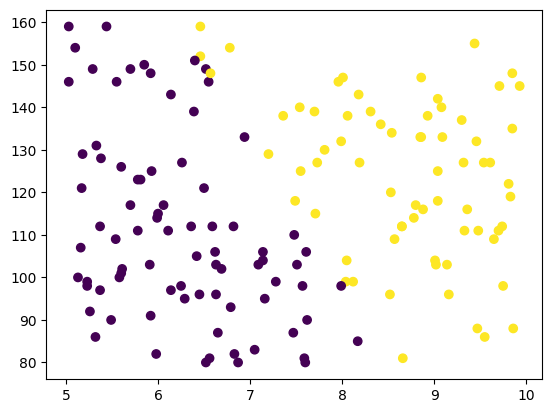

In [4]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [5]:
X=df.iloc[:, 0:2]
y=df.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [8]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [10]:
clf.fit(X_train,y_train)

LogisticRegression()

In [11]:
y_pred=clf.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

<Axes: >

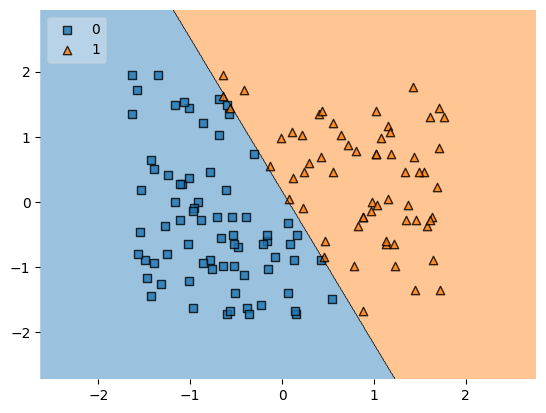

In [13]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [14]:
import pickle


In [15]:
pickle.dump(clf, open('model.pkl', 'wb'))